C:\Users\au617715\AppData\Local\Temp\ipykernel_23580\3576477648.py:24: DeprecationWarning: `plot_probe_group` is deprecated and will be removed in 2.23. Use plot_probegroup instead
  plot_probe_group(probe)


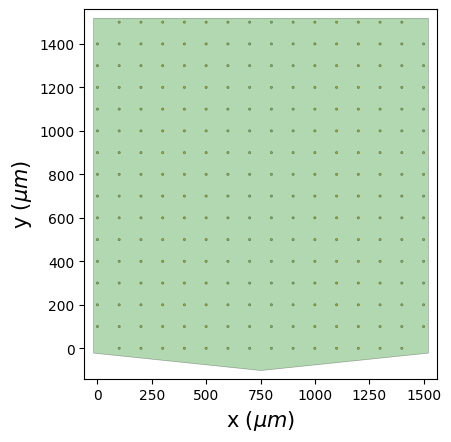

In [1]:
%load_ext autoreload
%autoreload 2

from tqdm.auto import tqdm
import spikeinterface.full as si
import numpy as np
import os
import scipy

from utils import (
    recording_onsets,
    run_minimal_sanity_check,
    save_obj,
    load_obj,
    pair_onsets_offsets
)

import probeinterface as pi
from probeinterface.plotting import plot_probe_group, plot_probe

# Load probe
probe = pi.read_prb('256mea_100_30iR_ITO.prb')

plot_probe_group(probe)
import matplotlib.pyplot as plt

def find_files(path):
    if os.path.isfile(os.path.normpath(path)):                                      #Check if given path is a file and if it exist
        with open(os.path.normpath(path)) as file:                                      #If yes, than open in variable "file"
            return file.read().splitlines()                                                 #return the text of each line as a file name ordered from top to bottom
    return [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]       #If no, the path is considered as a folder and return the name of all the files in alphabetic order


def load_data(input_path, dtype='uint16', nb_channels=256, channel_id=127, probe_size=None, voltage_resolution=0.1042, disable=False):
    
    # Load data.
    m = np.memmap(os.path.normpath(input_path),dtype=dtype)
    
    #Input file sanity check
    if m.size % nb_channels != 0:
        message = "number of channels is inconsistent with the data size."
        raise Exception(message)
    
    
    nb_samples = m.size // nb_channels
    
    if probe_size:
        nb_samples = min(probe_size,nb_samples)
    
    data = np.empty((nb_samples,), dtype=dtype)
    for k in tqdm(range(nb_samples),disable = disable):
        data[k] = m[nb_channels * k + channel_id]
    data = data.astype(np.float64)
    data = data - np.iinfo('uint16').min + np.iinfo('int16').min
    data = data / voltage_resolution
    
    return data, nb_samples


def detect_onsets(data, threshold=170e+3):
    """
    Function to compute time point in the data coresponding to the display of a new frame of the stimuli based on trigger recording
    Input :
        - data (1D numpy array) : raw triggers data
        - threshold (int) : voltage value that detects onsets in data
        
    Output :
        - indices (1D numpy array) : list of time indices corresponding to the detected onsets time point
        
    Possible mistakes :
        - Threshold is no longer optimum and has to be changed
        - Wrong mea given as parameters
        - Data coming from the wrong channel
    """
    test_1 = data[:-1] < threshold
    test_2 = data[1:] >= threshold
    test = np.logical_and(test_1, test_2)
    
    indices = np.where(test)[0]
    
    test = data[indices - 1] < data[indices]
    while np.any(test):
        indices[test] = indices[test] - 1
        test = data[indices - 1] < data[indices]
    
    return indices

def detect_offsets(data,threshold=170e+3):
    
    test_1 = data[:-1] > threshold
    test_2 = data[1:] <= threshold
    test = np.logical_and(test_1, test_2)
    
    indices = np.where(test)[0]
    
    test = data[indices - 1] < data[indices]
    while np.any(test):
        indices[test] = indices[test] - 1
        test = data[indices - 1] < data[indices]
    
    return indices

In [2]:
import os
from pathlib import Path
from tkinter import Tk, filedialog

# Select project folder
Tk().withdraw()

project_dir = filedialog.askdirectory(
    title="Select folder containing remove_artefacts.ipynb, params.py and ressources"
)

if not project_dir:
    raise SystemExit("No folder selected")

# Set working directory
os.chdir(project_dir)

print("Working directory:")
print(os.getcwd())

probe_file = Path ("256mea_100_30iR_ITO.prb")

print("\nProbe file:")
print(probe_file.absolute())

if not probe_file.is_file():
    raise FileNotFoundError(
        f"\nCould not find:\n{probe_file.absolute()}\n\n"
        f"Make sure you selected the folder containing:\n"
        f"  params.py\n"
        f"  remove_artefacts.ipynb\n"
        f"  ressources\\256mea_100_30iR_ITO.prb"
    )

print("\n✓ Probe file found")


Working directory:
D:\ACJ\20260528\20260528 PV chip rd1 764 eye1 1st half\RAW

Probe file:
D:\ACJ\20260528\20260528 PV chip rd1 764 eye1 1st half\RAW\256mea_100_30iR_ITO.prb

✓ Probe file found


# Open files

In [3]:
import params
print(params.__file__)
os.path.split(params.symbolic_link_directory)[1]

d:\ACJ\20260528\20260528 PV chip rd1 764 eye1 1st half\RAW\params.py


'RAW'

Small diagnostic code to check whether the files are in the correct spot.

In [4]:
import os

print("Recording directory:")
print(params.recording_directory)

print("\nContents:")
print(os.listdir(params.recording_directory))

Recording directory:
D:\ACJ\20260528\20260528 PV chip rd1 764 eye1 1st half\RAW

Contents:
['256mea_100_30iR_ITO.prb', 'params.py', 'rec_01_1-pow_N_P.raw', 'rec_02_1-pow_N_P.raw', 'rec_03_2-pow_N_L.raw', 'rec_04_3-pow_LC_B.raw', 'rec_05_4-dur_N_P.raw', 'rec_06_5-dur_N_L.raw', 'rec_07_5-dur_N_L.raw', 'rec_08_6-dur_LC_B.raw', 'rec_09_7-freq_N_P.raw', 'rec_10_8-freq_N_L.raw', 'rec_11_9-freq_LC_B.raw', 'rec_12_10-del_N_B.raw', 'rec_13_11-flick_N_L.raw', 'rec_14_12-longstim_N_P.raw', 'Remove_artefacts_modified_v2.ipynb', 'utils.py', '__pycache__']


In [5]:
"""
    Input
"""

fs = params.fs

root = params.registration_directory

exp = params.exp

raw_folder = params.recording_directory
recording_directory = raw_folder

triggers_directory = params.triggers_directory

frames_path = os.path.join(root, "frames")

saving_directory = params.raw_filtered_directory

recording_names = params.recording_names




"""
    Processing
"""

recording_names = [rec.replace('.raw','') for rec in recording_names]
rec_it = recording_names[:]+['end']
print('Number of recordings: {}\n'.format(len(recording_names)))

#getting onset for next prints
onsets = {}
onsets = recording_onsets(recording_names, path = recording_directory)

#Opening files
print('\nCheck that recordings lengths are consistent with recording names\n') 


for i in range(len(rec_it)-1):    
    print("{} minutes\t--->\t{} : {} -> OK".format(int((onsets[rec_it[i+1]]-onsets[rec_it[i]])/fs/60), i, rec_it[i]))


"""Output :

Var :
recordings_names : Ordered list of stimuli names played during experiment
"""   

print('\n\t\t\t------ End Of Cell ------')

Number of recordings: 14


Check that recordings lengths are consistent with recording names

1 minutes	--->	0 : rec_01_1-pow_N_P -> OK
1 minutes	--->	1 : rec_02_1-pow_N_P -> OK
1 minutes	--->	2 : rec_03_2-pow_N_L -> OK
1 minutes	--->	3 : rec_04_3-pow_LC_B -> OK
1 minutes	--->	4 : rec_05_4-dur_N_P -> OK
0 minutes	--->	5 : rec_06_5-dur_N_L -> OK
9 minutes	--->	6 : rec_07_5-dur_N_L -> OK
2 minutes	--->	7 : rec_08_6-dur_LC_B -> OK
1 minutes	--->	8 : rec_09_7-freq_N_P -> OK
1 minutes	--->	9 : rec_10_8-freq_N_L -> OK
1 minutes	--->	10 : rec_11_9-freq_LC_B -> OK
1 minutes	--->	11 : rec_12_10-del_N_B -> OK
1 minutes	--->	12 : rec_13_11-flick_N_L -> OK
10 minutes	--->	13 : rec_14_12-longstim_N_P -> OK

			------ End Of Cell ------


# Extract laser times

## With Trigger Channel

In [6]:
"""
    Inputs
"""

# ---------------------------------------------------------
# Overwrite existing trigger files
# ---------------------------------------------------------

overwrite_trigger_files = True

# ---------------------------------------------------------
# Manual stimulation modality override
#
# Format:
# recording_index : {'laser': bool, 'poly': bool}
#
# Example:
# 3 : {'laser': True, 'poly': False}
# ---------------------------------------------------------

# EXAMPLE
#manual_trigger_override = {
#
#    2: {'laser': True,  'poly': True},
#
#    5: {'laser': False, 'poly': True},
#
#   8: {'laser': True,  'poly': False},
#
#}

manual_trigger_override = {

}

# ---------------------------------------------------------
# Diagnostic verbosity
#
# True  -> show detailed diagnostics
# False -> compact output
# ---------------------------------------------------------

verbose = False

def vprint(*args, **kwargs):
    """
    Verbose print helper
    """
    if verbose:
        print(*args, **kwargs)

#you can decide here to extract the triggers only for some recordings. List their indexes here (starting from 0).
select_rec = []    # do only measurement N, put [] or the complet list to call all of them

# ---------------------------------------------------------
# Artefact removal parameters
# ---------------------------------------------------------
#
#artefact_removal_method = 'zeros'
#
#artefact_ms_before = 5
#artefact_ms_after  = 5

"""
    Variable
    
    You will find here all variables used
    
    in this notebook cell. They should always refere to your 'params.py' file
    except if you want to manually change some variable only for this run (i.e. debugging). You may have to add those
    variable into the function you want to adapt as only the minimal amount of var are currently given to functions as inputs.
"""

# ---------------------------------------------------------
# Parameters from params.py
# ---------------------------------------------------------

MEA = params.MEA

laser_threshold = params.laser_threshold
poly_threshold  = params.poly_threshold

Nchannels = params.nb_channels

fs = params.fs

probe_size = params.probe_size

#Channel recording triggers in case of laser stimuli
laser_channel_id = params.laser_channel_id

#Channel recording triggers in case of poly stimuli
poly_channel_id  = params.poly_channel_id


"""
    Processing
"""

for rec in range(len(recording_names)):
    if select_rec:
        if rec not in select_rec: continue
    
    print('\n-------------   Processing recording {} out of {}   -------------\n'.format(rec+1,len(recording_names)))

    # Creating all files path
    input_file    = os.path.join(recording_directory,recording_names[rec]+'.raw')
    trigger_file  = os.path.join(triggers_directory,'{}_{}_triggers.pkl'.format(exp,recording_names[rec]))
    data_file     = os.path.join(triggers_directory,'{}_{}_triggers_data.pkl'.format(exp,recording_names[rec]))
    
    print('The triggers are extracted from the sorting file:\t{}\nand the results will be saved at:\t\t\t{}'.format(recording_names[rec]+'.raw',trigger_file))
    # ---------------------------------------------------------
    # Skip existing trigger extraction unless overwrite enabled
    # ---------------------------------------------------------

    if os.path.exists(data_file) and not overwrite_trigger_files:

        print("Trigger files already exist -> skipping")
        continue

    elif os.path.exists(data_file) and overwrite_trigger_files:

        print("Overwriting existing trigger files")
        
#    is_laser = False
    
    # ---------------------------------------------------------
    # Initialise trigger containers
    # ---------------------------------------------------------

    indices_poly = np.array([])
    offsets_poly = np.array([])
    pairs_poly   = np.empty((0, 2), dtype=int)
    errors_poly  = np.array([])

    indices_laser = np.array([])
    offsets_laser = np.array([])
    pairs_laser   = np.empty((0, 2), dtype=int)
    errors_laser  = np.array([])
    
    # ==========================================================
    # POLYCHROME CHANNEL
    # ==========================================================

    vprint("\n--- POLYCHROME channel ---")

    data_poly, t_tot = load_data(
        input_file,
        channel_id=poly_channel_id
    )

    vprint("Signal diagnostics (POLYCHROME)")
    vprint("Min:", data_poly.min())
    vprint("Max:", data_poly.max())
    vprint("Threshold:", poly_threshold)

    samples_above_poly = np.sum(data_poly > poly_threshold)

    contains_poly = samples_above_poly > 0
    # ---------------------------------------------------------
    # Manual override
    # ---------------------------------------------------------

    if rec in manual_trigger_override:

        contains_poly = manual_trigger_override[rec]['poly']

        print(
            "Manual override -> "
            f"contains_poly = {contains_poly}"
        )

    vprint("Samples above threshold:", samples_above_poly)
    vprint("Detected polychrome stimulation:", contains_poly)

    if contains_poly:

        indices_poly = detect_onsets(
            data_poly,
            poly_threshold
        )

        offsets_poly = detect_offsets(
            data_poly,
            poly_threshold
        )
        
        pairs_poly = pair_onsets_offsets(
            indices_poly,
            offsets_poly
        )

        vprint("Detected POLYCHROME onsets:", len(indices_poly))
        vprint("Detected POLYCHROME offsets:", len(offsets_poly))

        errors_poly = run_minimal_sanity_check(
            indices_poly,
            stim_type='polychrome'
        )


    # ==========================================================
    # LASER CHANNEL
    # ==========================================================

    vprint("\n--- LASER channel ---")

    data_laser, _ = load_data(
        input_file,
        channel_id=laser_channel_id
    )

    vprint("Signal diagnostics (LASER)")
    vprint("Min:", data_laser.min())
    vprint("Max:", data_laser.max())
    vprint("Threshold:", laser_threshold)

    samples_above_laser = np.sum(data_laser > laser_threshold)

    contains_laser = samples_above_laser > 0
    
    # ---------------------------------------------------------
    # Manual override
    # ---------------------------------------------------------

    if rec in manual_trigger_override:

        contains_laser = manual_trigger_override[rec]['laser']

        print(
            "Manual override -> "
            f"contains_laser = {contains_laser}"
        )

    vprint("Samples above threshold:", samples_above_laser)
    vprint("Detected laser stimulation:", contains_laser)

    if contains_laser:

        indices_laser = detect_onsets(
            data_laser,
            laser_threshold
        )

        offsets_laser = detect_offsets(
            data_laser,
            laser_threshold
        )
        
        pairs_laser = pair_onsets_offsets(
            indices_laser,
            offsets_laser
        )

        vprint("Detected LASER onsets:", len(indices_laser))
        vprint("Detected LASER offsets:", len(offsets_laser))

        errors_laser = run_minimal_sanity_check(
            indices_laser,
            stim_type='laser'
        )


    # ==========================================================
    # SAVE TRIGGER STRUCTURE
    # ==========================================================

    save_obj({

        'poly': {
            'indices': indices_poly,
            'offsets': offsets_poly,
            'pairs': pairs_poly,
            'errors': errors_poly,
        },

        'laser': {
            'indices': indices_laser,
            'offsets': offsets_laser,
            'pairs': pairs_laser,
            'errors': errors_laser,
        },

        'duration': t_tot,

        'contains_poly': contains_poly,
        'contains_laser': contains_laser,

    }, trigger_file)


    # ==========================================================
    # SAVE RAW TRIGGER CHANNELS
    # ==========================================================

    save_obj({

        'poly_data': data_poly,
        'laser_data': data_laser

    }, data_file)   
        
"""
    Output

Saved in triggers_directory :

---------------------------------------------------------
{experiment}_{recording}_triggers.pkl
---------------------------------------------------------

Dictionary containing:

{
    'poly': {

        'indices' : detected onset indices
        'offsets' : detected offset indices
        'pairs'   : onset-offset pairs
        'errors'  : sanity check violations

    },

    'laser': {

        'indices' : detected onset indices
        'offsets' : detected offset indices
        'pairs'   : onset-offset pairs
        'errors'  : sanity check violations

    },

    'duration' : recording duration in samples

    'contains_poly'  : bool
    'contains_laser' : bool
}

---------------------------------------------------------
{experiment}_{recording}_triggers_data.pkl
---------------------------------------------------------

Dictionary containing raw trigger channels:

{
    'poly_data'  : raw polychrome trigger signal
    'laser_data' : raw laser trigger signal
}
"""
print('\n\t\t\t------ End Of Cell ------')


-------------   Processing recording 1 out of 14   -------------

The triggers are extracted from the sorting file:	rec_01_1-pow_N_P.raw
and the results will be saved at:			D:\ACJ\20260528\20260528 PV chip rd1 764 eye1 1st half\Analysis\trigs\20260528_PV_chip_rd1_764_eye1_1st_half_rec_01_1-pow_N_P_triggers.pkl


  0%|          | 0/2174000 [00:00<?, ?it/s]

Minimal sanity checks :	/!\ Triggers are not evenly spaced /!\ 
Number of errors : 5
Maximum error : 210031 sampling points compared to 10001 sampling points per trigger


  0%|          | 0/2174000 [00:00<?, ?it/s]


-------------   Processing recording 2 out of 14   -------------

The triggers are extracted from the sorting file:	rec_02_1-pow_N_P.raw
and the results will be saved at:			D:\ACJ\20260528\20260528 PV chip rd1 764 eye1 1st half\Analysis\trigs\20260528_PV_chip_rd1_764_eye1_1st_half_rec_02_1-pow_N_P_triggers.pkl


...

Minimal sanity checks :	/!\ Triggers are not evenly spaced /!\ 
Number of errors : 299
Maximum error : 209030 sampling points compared to 120 sampling points per trigger

-------------   Processing recording 14 out of 14   -------------

The triggers are extracted from the sorting file:	rec_14_12-longstim_N_P.raw
and the results will be saved at:			D:\ACJ\20260528\20260528 PV chip rd1 764 eye1 1st half\Analysis\trigs\20260528_PV_chip_rd1_764_eye1_1st_half_rec_14_12-longstim_N_P_triggers.pkl


  0%|          | 0/12462000 [00:00<?, ?it/s]

Minimal sanity checks :	/!\ Triggers are not evenly spaced /!\ 
Number of errors : 120
Maximum error : 300041 sampling points compared to 65009 sampling points per trigger


  0%|          | 0/12462000 [00:00<?, ?it/s]


			------ End Of Cell ------


## With Axorus Pain

# Process Recordings

In [7]:
# ==========================================================
# Artefact removal settings
# ==========================================================

artefact_ms_before = 5
artefact_ms_after  = 10

# ==========================================================

artefact_removal_method = 'zeros'

print(
    f"Artefact removal window: "
    f"{artefact_ms_before} ms before, "
    f"{artefact_ms_after} ms after"
)

recordings = {}
for recording_name in recording_names:
    recordings[recording_name] = {}
    
    extracted = load_obj(os.path.normpath(os.path.join(triggers_directory,'{}_{}_triggers.pkl'.format(exp,recording_name))))
    
    # ==========================================================
    # Open recording
    # ==========================================================

    recordings[recording_name]['raw'] = si.read_binary(
        os.path.join(recording_directory, recording_name + '.raw'),
        sampling_frequency=fs,
        num_channels=Nchannels,
        dtype='uint16'
    )

    print(f"{recording_name}")
    print("--> raw opened")


    # ==========================================================
    # Bandpass filter
    # ==========================================================

    recordings[recording_name]['si_filtered'] = si.bandpass_filter(
        recordings[recording_name]['raw'],
        dtype="float32"
    )

    print("--> bandpass filtered")


    # ==========================================================
    # Common median reference
    # ==========================================================

    recordings[recording_name]['si_filtered_medianremoved'] = (
        si.common_reference(
            recordings[recording_name]['si_filtered']
        )
    )

    print("--> common median referenced")
    
    # ==========================================================
    # Collect artefact trigger times
    # ==========================================================

    times = np.array([])

    # ---------- POLYCHROME ----------
    if extracted['contains_poly']:

        poly_onsets  = extracted['poly']['indices']
        poly_offsets = extracted['poly']['offsets']

        times = np.concatenate((
            times,
            poly_onsets,
            poly_offsets
        ))

        print("--> polychrome artefacts detected")

    # ---------- LASER ----------
    if extracted['contains_laser']:

        laser_onsets  = extracted['laser']['indices']
        laser_offsets = extracted['laser']['offsets']

        times = np.concatenate((
            times,
            laser_onsets,
            laser_offsets
        ))

        print("--> laser artefacts detected")

    # ==========================================================
    # Remove artefacts if any exist
    # ==========================================================

    if len(times) > 0:

        times = np.sort(times)

        recordings[recording_name]['si_cleaned_zeros'] = (
            si.remove_artifacts(
                recordings[recording_name]['si_filtered_medianremoved'],
                list_triggers=[list(times)],
                ms_before=artefact_ms_before,
                ms_after=artefact_ms_after,
                mode=artefact_removal_method
            )
        )

        print("--> artefacts removed")

    else:

        recordings[recording_name]['si_cleaned_zeros'] = (
            recordings[recording_name]['si_filtered_medianremoved']
        )

        print("--> no artefacts detected")
    
    print('\n')


print('\n\t\t\t------ End Of Cell ------')

Artefact removal window: 5 ms before, 10 ms after
rec_01_1-pow_N_P
--> raw opened
--> bandpass filtered
--> common median referenced
--> polychrome artefacts detected
--> artefacts removed


rec_02_1-pow_N_P
--> raw opened
--> bandpass filtered
--> common median referenced
--> polychrome artefacts detected
--> artefacts removed


rec_03_2-pow_N_L
--> raw opened
--> bandpass filtered
--> common median referenced
--> laser artefacts detected
--> artefacts removed


rec_04_3-pow_LC_B
--> raw opened
--> bandpass filtered
--> common median referenced
--> polychrome artefacts detected
--> laser artefacts detected
--> artefacts removed


rec_05_4-dur_N_P
--> raw opened
--> bandpass filtered
--> common median referenced
--> polychrome artefacts detected
--> artefacts removed


rec_06_5-dur_N_L
--> raw opened
--> bandpass filtered
--> common median referenced
--> polychrome artefacts detected
--> artefacts removed


rec_07_5-dur_N_L
--> raw opened
--> bandpass filtered
--> common median referen

In [8]:
#Manually adding times to remove with 10ms 0 window
times = []

artefact_removal_method = 'zeros'

print(*['{} : {}'.format(i,recording_name) for i, recording_name in enumerate(recordings.keys())], sep="\n")
recording_name = recording_names[int(input("\nSelected recording: "))]

recordings[recording_name]['manually_removed_triggers'] = si.remove_artifacts(recordings[recording_name]['si_cleaned_zeros'], 
                                                               list_triggers=[times], 
                                                               ms_before=5, 
                                                               ms_after=10, 
                                                               mode=artefact_removal_method)

0 : rec_01_1-pow_N_P
1 : rec_02_1-pow_N_P
2 : rec_03_2-pow_N_L
3 : rec_04_3-pow_LC_B
4 : rec_05_4-dur_N_P
5 : rec_06_5-dur_N_L
6 : rec_07_5-dur_N_L
7 : rec_08_6-dur_LC_B
8 : rec_09_7-freq_N_P
9 : rec_10_8-freq_N_L
10 : rec_11_9-freq_LC_B
11 : rec_12_10-del_N_B
12 : rec_13_11-flick_N_L
13 : rec_14_12-longstim_N_P


# Visualize artefact


Waveform window: 30 ms before, 30 ms after

Available recordings:
 0 : rec_01_1-pow_N_P
 1 : rec_02_1-pow_N_P
 2 : rec_03_2-pow_N_L
 3 : rec_04_3-pow_LC_B
 4 : rec_05_4-dur_N_P
 5 : rec_06_5-dur_N_L
 6 : rec_07_5-dur_N_L
 7 : rec_08_6-dur_LC_B
 8 : rec_09_7-freq_N_P
 9 : rec_10_8-freq_N_L
10 : rec_11_9-freq_LC_B
11 : rec_12_10-del_N_B
12 : rec_13_11-flick_N_L
13 : rec_14_12-longstim_N_P

Selected recording: rec_02_1-pow_N_P

Artefact grouping modes:
0 : all artefacts pooled together
1 : onsets separated from offsets
2 : poly separated from laser
3 : poly onset / poly offset / laser onset / laser offset

Selected grouping mode: onset_offset

Available trigger modalities:
0 : poly (onsets=120, offsets=120)

Selected modality: poly
Detected 120 onsets, 120 offsets
Times shape: (240,)
Labels shape: (240,)
Number of units: 2
Unit IDs: [0 1]

Available waveform units:
0 : poly onset artefacts (n=120)
1 : poly offset artefacts (n=120)

Selected waveform unit 0: poly onset artefacts
####
# ex

estimate_sparsity (workers: 4 processes):   0%|          | 0/220 [00:00<?, ?it/s]

compute_waveforms (workers: 4 processes):   0%|          | 0/220 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

####
# extract_waveforms() and WaveformExtractor() have been replaced by the `SortingAnalyzer` since version 0.101.0.
# You should use `spikeinterface.create_sorting_analyzer()` instead.
# `spikeinterface.extract_waveforms()` is now mocking the old behavior for backwards compatibility only,
# and may potentially be removed in a future version.
####
allow_unfiltered is ignored


estimate_sparsity (workers: 4 processes):   0%|          | 0/220 [00:00<?, ?it/s]

compute_waveforms (workers: 4 processes):   0%|          | 0/220 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

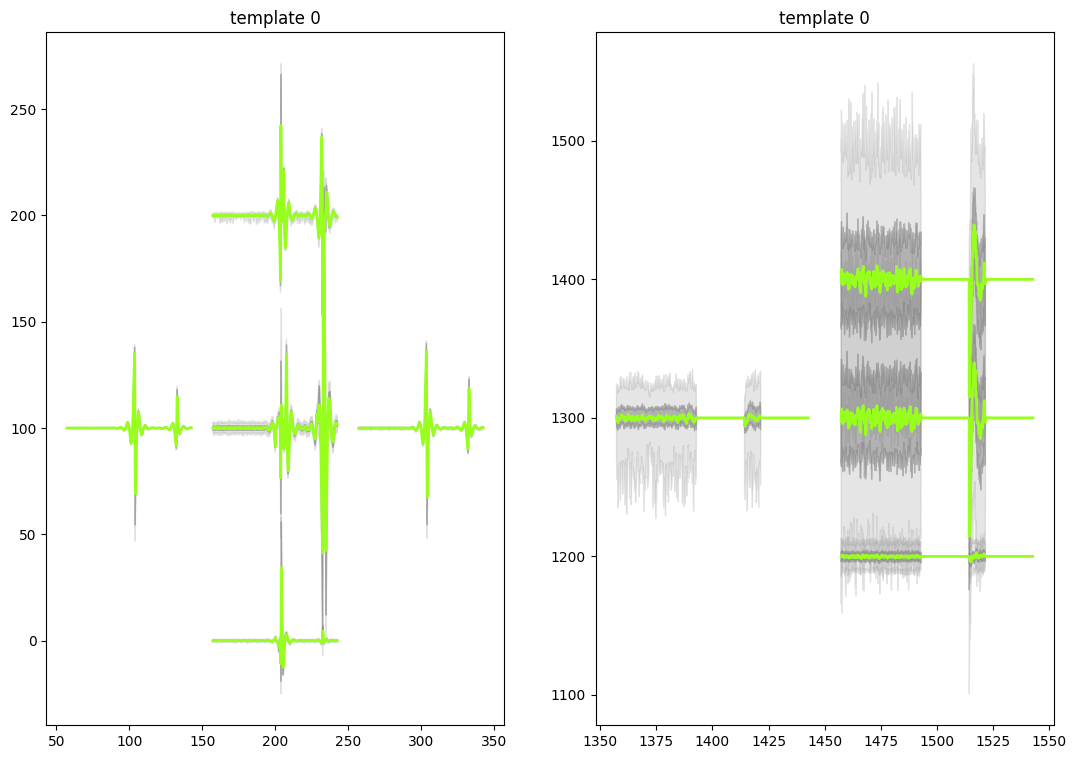

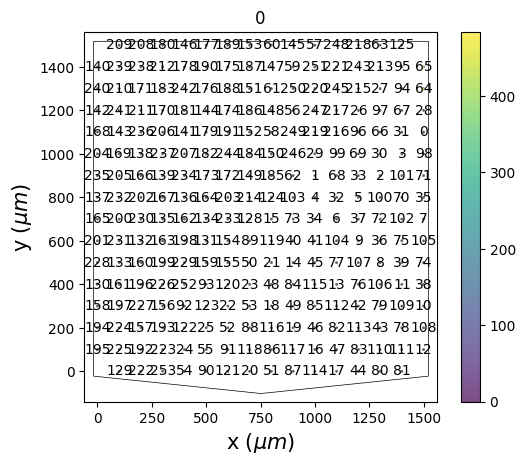

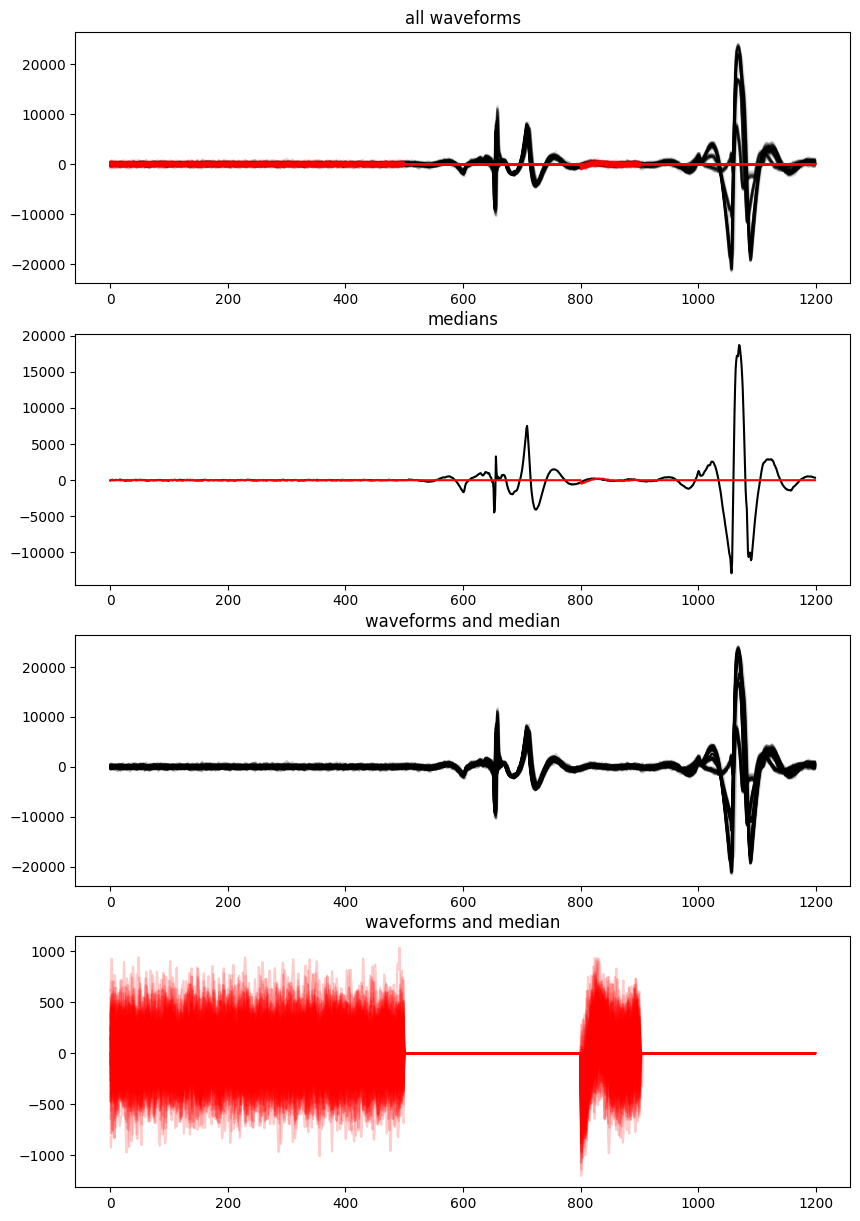


			------ End Of Cell ------


In [9]:
#import pylab as plt

elec = 1  #electrode number

# ---------------------------------------------------------
# Waveform extraction window
# ---------------------------------------------------------

waveform_ms_before = 30
waveform_ms_after  = 30

print(
    f"\nWaveform window: "
    f"{waveform_ms_before} ms before, "
    f"{waveform_ms_after} ms after"
)

# ---------------------------------------------------------

available_recordings = list(recordings.keys())

print("\nAvailable recordings:")
for i, rec_name in enumerate(available_recordings):
    print(f"{i:2d} : {rec_name}")

recording_idx = int(
    input("\nSelect recording index: ")
)

recording_name = available_recordings[recording_idx]

print(
    f"\nSelected recording: "
    f"{recording_name}"
)

#Onsets and offsets loading
extracted = load_obj(
    os.path.join(
        triggers_directory,
        '{}_{}_triggers.pkl'.format(exp, recording_name)
    )
)

# ---------------------------------------------------------
# Artefact grouping mode
#
# 'all'
#     All detected artefacts pooled into one group.
#     Useful for assessing the overall stimulation artefact.
#
# 'onset_offset'
#     Onset artefacts and offset artefacts analysed separately.
#     Useful for comparing laser/poly switch-on vs switch-off artefacts.
#
# 'modality'
#     Artefacts grouped by stimulation modality.
#     Intended future use:
#         unit 0 = polychrome
#         unit 1 = laser
#
# 'full'
#     Maximum separation of artefacts.
#     Intended future use:
#         unit 0 = polychrome onset
#         unit 1 = polychrome offset
#         unit 2 = laser onset
#         unit 3 = laser offset
#
# Current implementation:
#     'all'          -> one pooled unit
#     'onset_offset' -> onset vs offset
#     'modality'     -> behaves like 'all'
#     'full'         -> behaves like 'onset_offset'
# ---------------------------------------------------------

artefact_modes = {

    0: (
        'all',
        'all artefacts pooled together'
    ),

    1: (
        'onset_offset',
        'onsets separated from offsets'
    ),

    2: (
        'modality',
        'poly separated from laser'
    ),

    3: (
        'full',
        'poly onset / poly offset / laser onset / laser offset'
    ),
}

print("\nArtefact grouping modes:")

for k, (_, desc) in artefact_modes.items():

    print(f"{k} : {desc}")

artefact_label_mode = artefact_modes[
    int(input("\nSelect grouping mode: "))
][0]

print(
    f"\nSelected grouping mode: "
    f"{artefact_label_mode}"
)

#frames_folder_files = [f for f in os.listdir(frames_path) if os.path.isfile(os.path.join(frames_path, f))]
#print(*['{} : {}'.format(i,frame_file) for i, frame_file in enumerate(frames_folder_files)], sep="\n")
#frame_name = frames_folder_files[int(input(f"\nSelect the DH_frames file for the recording {recording_name} \n"))]

#Frames loading
#frames = scipy.io.loadmat(os.path.join(frames_path, frame_name))
#spot_order = np.array([i[0] for i in frames['OrderFrames']])

# ==========================================================
# Available trigger modalities
# ==========================================================

available_modalities = []

if extracted['contains_poly']:
    available_modalities.append('poly')

if extracted['contains_laser']:
    available_modalities.append('laser')

print("\nAvailable trigger modalities:")

for i, modality in enumerate(available_modalities):

    n_onsets = len(
        extracted[modality]['indices']
    )

    n_offsets = len(
        extracted[modality]['offsets']
    )

    print(
        f"{i} : {modality} "
        f"(onsets={n_onsets}, offsets={n_offsets})"
    )

trigger_modality = available_modalities[
    int(input("\nSelect modality: "))
]

print(
    f"\nSelected modality: "
    f"{trigger_modality}"
)

print(
    f"Detected "
    f"{len(extracted[trigger_modality]['indices'])} onsets, "
    f"{len(extracted[trigger_modality]['offsets'])} offsets"
)  

stim_onsets = extracted[trigger_modality]['indices']
stim_offsets = extracted[trigger_modality]['offsets']

# ==========================================================
# Match onset/offset counts
# ==========================================================

n_events = min(
    len(stim_onsets),
    len(stim_offsets)
)

stim_onsets = stim_onsets[:n_events]
stim_offsets = stim_offsets[:n_events]

# ==========================================================
# Build artefact events
# ==========================================================

event_times = []
event_labels = []

# ==========================================================
# Artefact grouping modes
# ==========================================================

"""
Mode descriptions

'all'
    All artefacts pooled together
    -> single unit

'onset_offset'
    Onsets pooled together
    Offsets pooled together
    -> two units

'modality'
    All artefacts from one modality pooled together
    -> currently equivalent to 'all'
       because only one modality is loaded at a time

'full'
    Intended future structure:
        poly onset
        poly offset
        laser onset
        laser offset

    Currently behaves like:
        onset_offset

"""

# ==========================================================
# ALL ARTEFACTS POOLED
# ==========================================================

if artefact_label_mode == 'all':

    event_times.extend(stim_onsets)
    event_times.extend(stim_offsets)

    event_labels.extend(
        [0] * (len(stim_onsets) + len(stim_offsets))
    )

# ==========================================================
# ONSET / OFFSET SEPARATED
# ==========================================================

elif artefact_label_mode == 'onset_offset':

    # unit 0 = onset artefacts
    event_times.extend(stim_onsets)
    event_labels.extend([0] * len(stim_onsets))

    # unit 1 = offset artefacts
    event_times.extend(stim_offsets)
    event_labels.extend([1] * len(stim_offsets))

# ==========================================================
# MODALITY SEPARATED
# ==========================================================

elif artefact_label_mode == 'modality':

    """
    Currently:
        poly OR laser only

    Future:
        poly = unit 0
        laser = unit 1
    """

    event_times.extend(stim_onsets)
    event_times.extend(stim_offsets)

    event_labels.extend(
        [0] * (len(stim_onsets) + len(stim_offsets))
    )

# ==========================================================
# FULL SEPARATION
# ==========================================================

elif artefact_label_mode == 'full':

    """
    Current implementation:
        onset vs offset

    Future implementation:
        poly onset   = unit 0
        poly offset  = unit 1
        laser onset  = unit 2
        laser offset = unit 3
    """

    # onset artefacts
    event_times.extend(stim_onsets)
    event_labels.extend([0] * len(stim_onsets))

    # offset artefacts
    event_times.extend(stim_offsets)
    event_labels.extend([1] * len(stim_offsets))

# ==========================================================
# INVALID MODE
# ==========================================================

else:

    raise ValueError(
        "artefact_label_mode must be one of:\n"
        "'all'\n"
        "'onset_offset'\n"
        "'modality'\n"
        "'full'"
    )

# ==========================================================
# Convert to arrays
# ==========================================================

times = np.array(event_times)
labels = np.array(event_labels)

# ==========================================================
# Chronological ordering
# ==========================================================

idx = np.argsort(times)

times = times[idx]
labels = labels[idx]

times = times.astype(np.int64)
labels = labels.astype(np.int64)

sorting = si.NumpySorting.from_samples_and_labels(
    times,
    labels,
    sampling_frequency=fs
)

print("Times shape:", times.shape)
print("Labels shape:", labels.shape)
print("Number of units:", len(sorting.unit_ids))
print("Unit IDs:", sorting.unit_ids)

# ==========================================================
# Unit descriptions
# ==========================================================

unit_descriptions = {}

if artefact_label_mode == 'all':

    unit_descriptions = {
        0: 'all artefacts pooled'
    }

elif artefact_label_mode == 'onset_offset':

    unit_descriptions = {
        0: f'{trigger_modality} onset artefacts',
        1: f'{trigger_modality} offset artefacts'
    }

elif artefact_label_mode == 'modality':

    unit_descriptions = {
        0: 'polychrome artefacts',
        1: 'laser artefacts'
    }

elif artefact_label_mode == 'full':

    if trigger_modality == 'poly':

        unit_descriptions = {
            0: 'polychrome onset artefacts',
            1: 'polychrome offset artefacts'
        }

    elif trigger_modality == 'laser':

        unit_descriptions = {
            0: 'laser onset artefacts',
            1: 'laser offset artefacts'
        }

# ==========================================================
# Print unit descriptions
# ==========================================================

print("\nAvailable waveform units:")

for unit_id in sorting.unit_ids:

    description = unit_descriptions.get(
        unit_id,
        f"unit {unit_id}"
    )

    n_events = len(
        sorting.get_unit_spike_train(unit_id)
    )

    print(
        f"{unit_id} : "
        f"{description} "
        f"(n={n_events})"
    )

# ==========================================================
# Select waveform unit
# ==========================================================

waveform_id = int(
    input("\nSelect waveform unit: ")
)

print(
    f"\nSelected waveform unit {waveform_id}: "
    f"{unit_descriptions[waveform_id]}"
)

waveforms = {}
waveforms['si_filtered_medianremoved'] = si.extract_waveforms(
    recordings[recording_name]['si_filtered_medianremoved'].set_probegroup(probe), 
    sorting,
    ms_before=waveform_ms_before,
    ms_after=waveform_ms_after,
    mode='memory',
    n_jobs=4,
    allow_unfiltered=True,
    chunk_memory="10M"
)

waveforms['si_cleaned_zeros'] = si.extract_waveforms(
    recordings[recording_name]['si_cleaned_zeros'].set_probegroup(probe), 
    sorting,
    ms_before=waveform_ms_before,
    ms_after=waveform_ms_after,
    mode='memory',
    n_jobs=4,
    allow_unfiltered=True,
    chunk_memory="10M"
)

# ==========================================================

## Plotting waveform with the probe plot

fig, axes = plt.subplots(1,2, figsize=(13,9))
si.plot_unit_templates(waveforms['si_filtered_medianremoved'], 
                       unit_ids=[waveform_id], same_axis=True, ax=axes[0], plot_legend=False)
si.plot_unit_templates(waveforms['si_cleaned_zeros'], 
                       unit_ids=[waveform_id], same_axis=True, ax=axes[1], plot_legend=False)

si.plot_unit_probe_map(waveforms['si_cleaned_zeros'], unit_ids=[waveform_id], with_channel_ids=True)


## Plotting waveform electrode wise  

unit_id = waveform_id

colors = ['k', 'r', 'b']

fig, axs = plt.subplots(4,1, figsize=(10,15))

ax = axs[0]
for i_key, key in enumerate(['si_filtered_medianremoved', 'si_cleaned_zeros']):
    wfs= waveforms[key].get_waveforms(unit_id=unit_id)
    for i_wf in range(wfs.shape[0]):
        ax.plot(wfs[i_wf,:,elec], color = colors[i_key],
                 label=key,
                alpha=0.1)
    ax.set_title("all waveforms")
        
ax = axs[1]
for i_key, key in enumerate(['si_filtered_medianremoved', 'si_cleaned_zeros']):
    wfs= waveforms[key].get_waveforms(unit_id=unit_id)
    ax.plot(np.median(wfs[:,:,elec],axis=0),
           color = colors[i_key])
    ax.set_title("medians")
        
for i_key, key in enumerate(['si_filtered_medianremoved', 'si_cleaned_zeros',]):
    ax = axs[i_key+2]

    wfs= waveforms[key].get_waveforms(unit_id=unit_id)
    for i_wf in range(wfs.shape[0]):
        ax.plot(wfs[i_wf,:,elec], color = colors[i_key],
                 label=key,
                alpha=0.2)
    ax.plot(np.median(wfs[:,:,elec],axis=0),
           color = colors[i_key])

    ax.set_title("waveforms and median")

plt.show(block=False)
print('\n\t\t\t------ End Of Cell ------')

# Visualize recording

0 : rec_01_1-pow_N_P
1 : rec_02_1-pow_N_P
2 : rec_03_2-pow_N_L
3 : rec_04_3-pow_LC_B
4 : rec_05_4-dur_N_P
5 : rec_06_5-dur_N_L
6 : rec_07_5-dur_N_L
7 : rec_08_6-dur_LC_B
8 : rec_09_7-freq_N_P
9 : rec_10_8-freq_N_L
10 : rec_11_9-freq_LC_B
11 : rec_12_10-del_N_B
12 : rec_13_11-flick_N_L
13 : rec_14_12-longstim_N_P


c:\Users\au617715\AppData\Local\miniconda3\envs\pipeline\lib\site-packages\spikeinterface\widgets\widget_list.py:167: UserWarning: plot_timeseries() is now plot_traces()
  warnings.warn("plot_timeseries() is now plot_traces()")


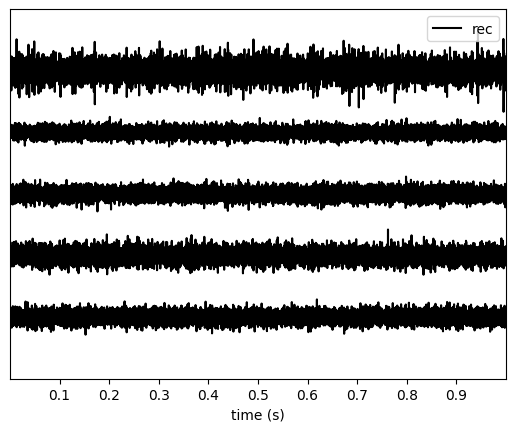

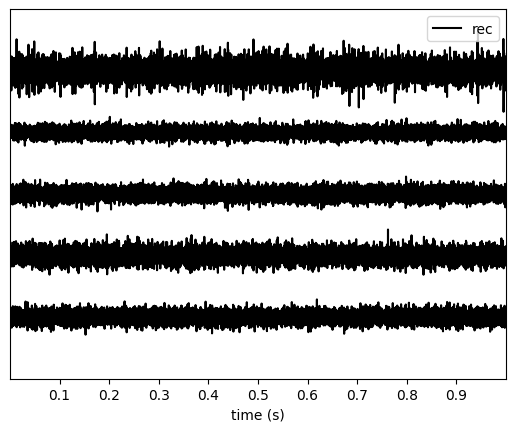

In [10]:
#Time range is the set of the first and lats second to plot
time_range = (0, 1)
ch_id = [10,52,112,198,236]

print(*['{} : {}'.format(i,recording_name) for i, recording_name in enumerate(recordings.keys())], sep="\n")
recording_name = recording_names[int(input("\nSelect holographic recording : "))]

try:
    si.plot_timeseries(recordings[recording_name]['si_cleaned_zeros'], time_range=time_range, channel_ids=ch_id)
except :
    pass

si.plot_timeseries(recordings[recording_name]['si_filtered_medianremoved'], time_range=time_range, channel_ids=ch_id)
plt.show(block='False')

# Export New Raw

In [11]:
print(params.raw_filtered_directory)

D:\ACJ\20260528\20260528 PV chip rd1 764 eye1 1st half\Analysis\raw_filtered


### Caution !! New written files are on int16 and not unit16 !!! Change this in your circus param file

In [12]:
import inspect
print(inspect.signature(si.write_binary_recording))

(recording: "'BaseRecording'", file_paths: 'list[Path | str] | Path | str', dtype: 'np.typing.DTypeLike' = None, add_file_extension: 'bool' = True, byte_offset: 'int' = 0, verbose: 'bool' = False, **job_kwargs)


In [13]:
if not os.path.exists(saving_directory): os.makedirs(saving_directory)

print(f"Saving filtered files in folder : {saving_directory}\n")
    
selected_files = []      #Choose here to write only specific recordings (index in the recording names list). If empty list, all recordings are being written
    
for rec_idx, recording_name in enumerate(recordings.keys()):
    
    if selected_files :
        if rec_idx not in selected_files : 
            continue
            
    
    if 'manually_removed_tirggers' in recordings[recording_name].keys():
        saving_name = recording_name + r'_Manually_Filtered_Cleaned_Zeros.raw'
        recording_to_save = recordings[recording_name]['manually_removed_tirggers']
    
    elif "si_cleaned_zeros" in recordings[recording_name].keys():      
        saving_name = recording_name + r'_Filtered_Cleaned_Zeros.raw'
        recording_to_save = recordings[recording_name]['si_cleaned_zeros']
        
    else:
        saving_name = recording_name + r'_Filtered.raw'
        recording_to_save = recordings[recording_name]['si_filtered_medianremoved']
        
    print(f"{saving_name} :")
    si.write_binary_recording(
        recording_to_save,
        file_paths=os.path.join(saving_directory,saving_name),
        dtype='int16',
        add_file_extension=True,
        verbose=True,
        byte_offset=0,
        n_jobs=10,
        progress_bar=True
    )
print("\nEND")

Saving filtered files in folder : D:\ACJ\20260528\20260528 PV chip rd1 764 eye1 1st half\Analysis\raw_filtered

rec_01_1-pow_N_P_Filtered_Cleaned_Zeros.raw :
write_binary_recording 
engine=process - n_jobs=10 - samples_per_chunk=20,000 - chunk_memory=19.53 MiB - total_memory=195.31 MiB - chunk_duration=1.00s


write_binary_recording (workers: 10 processes):   0%|          | 0/109 [00:00<?, ?it/s]

rec_02_1-pow_N_P_Filtered_Cleaned_Zeros.raw :
write_binary_recording 
engine=process - n_jobs=10 - samples_per_chunk=20,000 - chunk_memory=19.53 MiB - total_memory=195.31 MiB - chunk_duration=1.00s


write_binary_recording (workers: 10 processes):   0%|          | 0/109 [00:00<?, ?it/s]

rec_03_2-pow_N_L_Filtered_Cleaned_Zeros.raw :
write_binary_recording 
engine=process - n_jobs=10 - samples_per_chunk=20,000 - chunk_memory=19.53 MiB - total_memory=195.31 MiB - chunk_duration=1.00s


...

rec_13_11-flick_N_L_Filtered_Cleaned_Zeros.raw :
write_binary_recording 
engine=process - n_jobs=10 - samples_per_chunk=20,000 - chunk_memory=19.53 MiB - total_memory=195.31 MiB - chunk_duration=1.00s


write_binary_recording (workers: 10 processes):   0%|          | 0/82 [00:00<?, ?it/s]

rec_14_12-longstim_N_P_Filtered_Cleaned_Zeros.raw :
write_binary_recording 
engine=process - n_jobs=10 - samples_per_chunk=20,000 - chunk_memory=19.53 MiB - total_memory=195.31 MiB - chunk_duration=1.00s


write_binary_recording (workers: 10 processes):   0%|          | 0/624 [00:00<?, ?it/s]


END


0 : rec_01_1-pow_N_P_Filtered_Cleaned_Zeros.raw
1 : rec_02_1-pow_N_P_Filtered_Cleaned_Zeros.raw
2 : rec_03_2-pow_N_L_Filtered_Cleaned_Zeros.raw
3 : rec_04_3-pow_LC_B_Filtered_Cleaned_Zeros.raw
4 : rec_05_4-dur_N_P_Filtered_Cleaned_Zeros.raw
5 : rec_06_5-dur_N_L_Filtered_Cleaned_Zeros.raw
6 : rec_07_5-dur_N_L_Filtered_Cleaned_Zeros.raw
7 : rec_08_6-dur_LC_B_Filtered_Cleaned_Zeros.raw
8 : rec_09_7-freq_N_P_Filtered_Cleaned_Zeros.raw
9 : rec_10_8-freq_N_L_Filtered_Cleaned_Zeros.raw
10 : rec_11_9-freq_LC_B_Filtered_Cleaned_Zeros.raw
11 : rec_12_10-del_N_B_Filtered_Cleaned_Zeros.raw
12 : rec_13_11-flick_N_L_Filtered_Cleaned_Zeros.raw
13 : rec_14_12-longstim_N_P_Filtered_Cleaned_Zeros.raw
rec_02_1-pow_N_P_Filtered_Cleaned_Zeros.raw


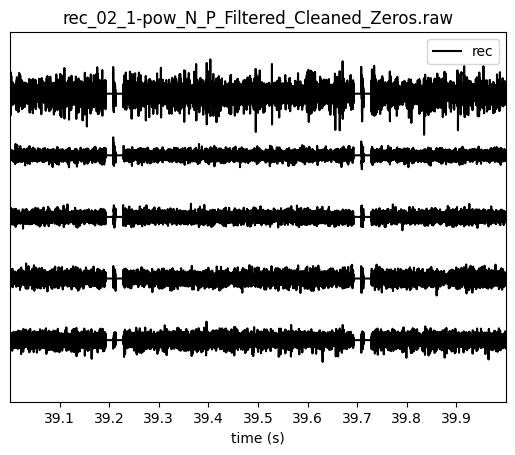

In [15]:
#Time range is the set of the first and lats second to plot
time_range=(39, 40)
ch_id = [10,52,112,198,236]

written_files = find_files(saving_directory)

print(*['{} : {}'.format(i,recording_name) for i, recording_name in enumerate(written_files)], sep="\n")
recording_name = written_files[int(input("\nSelect recording : "))]
print(recording_name)
recording = si.read_binary(
    os.path.join(saving_directory, recording_name),
    sampling_frequency=fs,
    num_channels=Nchannels,
    dtype='int16'
)




si.plot_timeseries(recording, time_range=time_range, channel_ids=ch_id)
plt.title(recording_name)
plt.show(block='False')